# 03 — Network & Political Exposure

Visualize the social network graph, inspect block structure, and verify political exposure category distribution.

**Covers:** Issue 5 (network + political exposure)

In [1]:
import sys, os, random
sys.path.insert(0, os.path.abspath("../src"))

from gabm.abm.attributes.gender import GenderID, GenderMap
from gabm.abm.attributes.ethnicity import EthnicityID
from gabm.abm.attributes.income import IncomeID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.attributes.education import EducationID
from gabm.abm.attributes.region import RegionID
from gabm.abm.attributes.family import FamilyID
from gabm.abm.democracy.election import ElectionID

from cag.io.survey import load
from cag.abm.environment import SurveyedNation
from cag.abm.agent import SurveyedCitizen, PoliticalAgent
from cag.abm.attributes.ethnicity import SurveyEthnicityMap
from cag.abm.attributes.income import SurveyIncomeMap
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.education import SurveyEducationMap
from cag.abm.attributes.region import UKRegionMap
from cag.abm.attributes.family import SurveyFamilyMap
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteID, UKGE2019VoteMap
from cag.abm.democracy.elections.brexit import BrexitVoteID, BrexitVoteMap
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7
)
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

print("Imports OK")

Imports OK


## Load Survey Data & Create Agents

Load the full YouGov survey dataset and create the `SurveyedNation` environment with all 200+ citizen agents.

In [2]:
random.seed(42)
year = 2026

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

surveyed_nation = SurveyedNation(
    year=year, place="UK",
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

data = load("../data/yougov_survey_data/YouGovProcessedData.csv")

for i in range(len(data)):
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=surveyed_nation,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    surveyed_nation.agents_active[sc.id] = sc

print(f"Created {len(surveyed_nation.agents_active)} agents in SurveyedNation")

Created 1483 agents in SurveyedNation


## Step 1: Create Political Agents & Assign Exposure

Create two political agents (pro-climate A, anti-climate B), attach them to the nation, and run `assign_political_exposure()`. This classifies every citizen into one of four categories using a **10-rule priority system** based on voting history (Brexit + UKGE2019) and left-right self-placement:

| Rule | Category | Profile |
|---|---|---|
| 1 | `A-only` | Remain + Labour/Green/LibDem (echo chamber) |
| 2 | `B-only` | Leave + Conservative/Brexit (echo chamber) |
| 3-4 | `both` | Cross-pressured: Leave+Labour or Remain+Conservative |
| 5-6 | `both` | Partial signal: one known Brexit vote, GE unknown |
| 7-8 | `both` | Partial signal: Brexit unknown, one known party |
| 9 | `both` | Politics-only signal: left-right placement but no clear votes |
| 10 | `neither` | Truly disengaged: DK/Unknown on all three dimensions |

The key design goal is to minimise the "neither" group (~5%) to match literature estimates of truly politically disengaged citizens (Prior 2007, Fletcher & Nielsen 2017). Any directional political signal routes an agent to "both" rather than "neither".

In [3]:
# Create and attach political agents
surveyed_nation.political_agent_a = PoliticalAgent("political_agent_a", "pro_climate")
surveyed_nation.political_agent_b = PoliticalAgent("political_agent_b", "anti_climate")

# Assign exposure categories based on voting history
surveyed_nation.assign_political_exposure()

# Count exposure distribution
exposure_counts = Counter(c.political_exposure for c in surveyed_nation.agents_active.values())
total = len(surveyed_nation.agents_active)

print("Political Exposure Distribution:")
print("-" * 40)
for cat in ["A-only", "B-only", "both", "neither"]:
    count = exposure_counts.get(cat, 0)
    pct = count / total * 100
    print(f"  {cat:10s}: {count:4d}  ({pct:.1f}%)")
print("-" * 40)
print(f"  Total     : {total:4d}")
print()
print(f"Agent A connected citizens: {len(surveyed_nation.political_agent_a.connected_citizens)}")
print(f"Agent B connected citizens: {len(surveyed_nation.political_agent_b.connected_citizens)}")

Political Exposure Distribution:
----------------------------------------
  A-only    :  405  (27.3%)
  B-only    :  285  (19.2%)
  both      :  725  (48.9%)
  neither   :   68  (4.6%)
----------------------------------------
  Total     : 1483

Agent A connected citizens: 1130
Agent B connected citizens: 1010


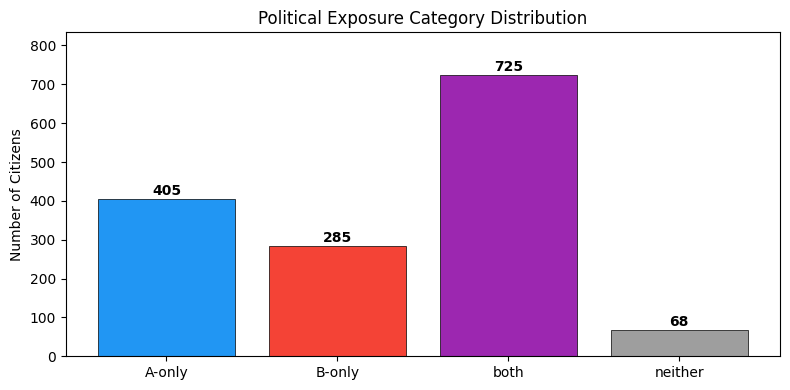

In [4]:
# Bar chart of exposure distribution
categories = ["A-only", "B-only", "both", "neither"]
counts = [exposure_counts.get(c, 0) for c in categories]
colors = ["#2196F3", "#F44336", "#9C27B0", "#9E9E9E"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(categories, counts, color=colors, edgecolor="black", linewidth=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(count), ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("Number of Citizens")
ax.set_title("Political Exposure Category Distribution")
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

## Step 2: Create the Stochastic Block Model Network

`create_network()` builds a NetworkX graph using `nx.stochastic_block_model()`. Citizens are assigned to two blocks based on their exposure category:
- **Block 0:** A-only citizens + half of both/neither (pro-climate leaning)
- **Block 1:** B-only citizens + other half of both/neither (anti-climate leaning)

Within-block connections (p_intra=0.15) are much more likely than cross-block connections (p_inter=0.02), modelling echo chambers with some cross-cutting exposure.

In [5]:
# Create the network (seed=42 for reproducibility)
G = surveyed_nation.create_network(seed=42)

print(f"Network type: {type(G).__name__}")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.1f}")

Network type: Graph
Nodes: 1483
Edges: 93851
Density: 0.0854
Average degree: 126.6


## Step 3: Assign Network Neighbors

`assign_network_blocks()` populates each citizen's `network_neighbors` list with references to their graph-adjacent citizens.

In [6]:
# Populate network_neighbors for every citizen
surveyed_nation.assign_network_blocks()

# Degree distribution stats
degrees = [len(c.network_neighbors) for c in surveyed_nation.agents_active.values()]
print(f"Neighbor count — min: {min(degrees)}, max: {max(degrees)}, mean: {sum(degrees)/len(degrees):.1f}")

# Show a sample citizen
sample = list(surveyed_nation.agents_active.values())[0]
print(f"\nSample citizen {sample.id}:")
print(f"  Exposure: {sample.political_exposure}")
print(f"  Neighbors: {len(sample.network_neighbors)}")
print(f"  Neighbor IDs (first 10): {[n.id for n in sample.network_neighbors[:10]]}")

Neighbor count — min: 88, max: 167, mean: 126.6

Sample citizen 1.0:
  Exposure: B-only
  Neighbors: 121
  Neighbor IDs (first 10): [np.float64(198.0), np.float64(331.0), np.float64(1006.0), np.float64(1174.0), np.float64(1225.0), np.float64(1264.0), np.float64(1328.0), np.float64(1526.0), np.float64(498.0), np.float64(568.0)]


## Visualize the Network

Color nodes by their political exposure category. The block structure should be visible — denser connections within blocks, sparser connections between.

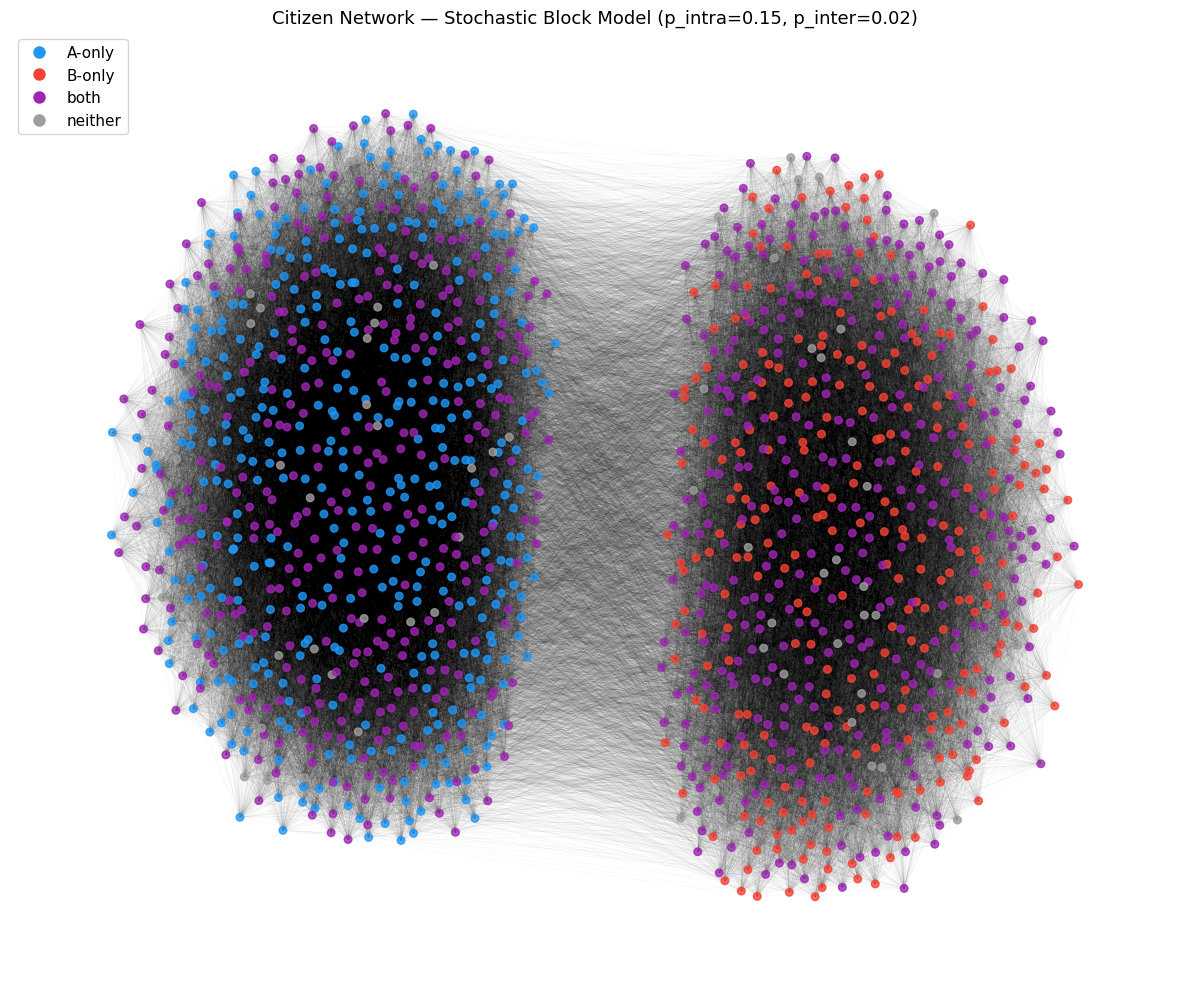

In [7]:
# Color map for exposure categories
color_map = {"A-only": "#2196F3", "B-only": "#F44336", "both": "#9C27B0", "neither": "#9E9E9E"}
node_colors = [color_map[surveyed_nation.agents_active[n].political_exposure] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=0.3)
nx.draw_networkx_edges(G, pos, alpha=0.05, width=0.3, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=30, alpha=0.8, ax=ax)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l)
                   for l, c in color_map.items()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
ax.set_title("Citizen Network — Stochastic Block Model (p_intra=0.15, p_inter=0.02)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

## Degree Distribution

Histogram of how many neighbors each citizen has. The SBM with p_intra=0.15 means ~15% of same-block citizens are connected, so typical degree ≈ block_size × 0.15.

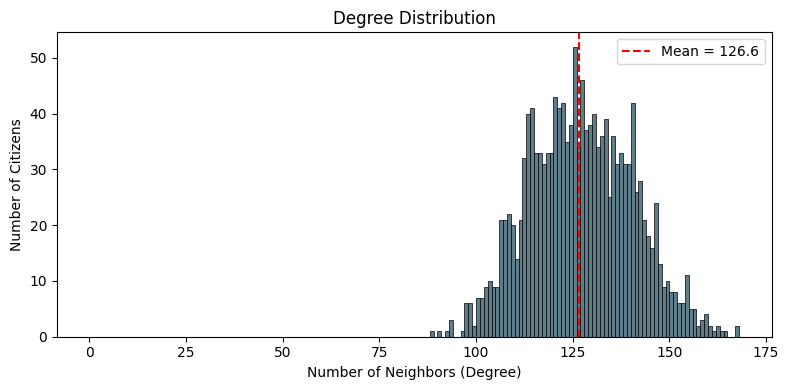

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(degrees, bins=range(0, max(degrees) + 2), edgecolor="black", linewidth=0.5, color="#607D8B")
ax.set_xlabel("Number of Neighbors (Degree)")
ax.set_ylabel("Number of Citizens")
ax.set_title("Degree Distribution")
ax.axvline(sum(degrees)/len(degrees), color="red", linestyle="--", label=f"Mean = {sum(degrees)/len(degrees):.1f}")
ax.legend()
plt.tight_layout()
plt.show()

## Seed Reproducibility Check

Verify that creating the network with the same seed produces identical results.

In [9]:
# Recreate network with same seed — should be identical
G2 = surveyed_nation.create_network(seed=42)
edges_match = set(G.edges()) == set(G2.edges())
print(f"Same seed (42) → edges identical: {edges_match}")

# Different seed — should differ
G3 = surveyed_nation.create_network(seed=99)
edges_differ = set(G.edges()) != set(G3.edges())
print(f"Different seed (99) → edges differ: {edges_differ}")

# Restore original network
surveyed_nation.create_network(seed=42)
surveyed_nation.assign_network_blocks()
print("Network restored to seed=42")

Same seed (42) → edges identical: True
Different seed (99) → edges differ: True
Network restored to seed=42


## Cross-Block vs Within-Block Edges

Check that the echo chamber structure is working: most edges should be within-block (intra), with fewer cross-block (inter) edges.

In [10]:
# Analyze block structure using the 'block' node attribute from the SBM
G = surveyed_nation.network
blocks = nx.get_node_attributes(G, 'block')

intra_edges = 0
inter_edges = 0
for u, v in G.edges():
    if blocks[u] == blocks[v]:
        intra_edges += 1
    else:
        inter_edges += 1

block_sizes = Counter(blocks.values())
total_edges = G.number_of_edges()

print(f"Block sizes: {dict(sorted(block_sizes.items()))}")
print(f"Intra-block edges: {intra_edges} ({intra_edges/total_edges:.1%})")
print(f"Inter-block edges: {inter_edges} ({inter_edges/total_edges:.1%})")
print(f"Ratio (intra/inter): {intra_edges/max(inter_edges,1):.1f}x")

Block sizes: {0: 802, 1: 681}
Intra-block edges: 82999 (88.4%)
Inter-block edges: 10852 (11.6%)
Ratio (intra/inter): 7.6x
